<a href="https://www.kaggle.com/code/soumyajitworkspace/notebook74epxeb956345?scriptVersionId=309210744" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

its simple

🚀 Training transformer to reverse sequences...
Epoch  30 | Loss: 2.0610
Epoch  60 | Loss: 1.7996
Epoch  90 | Loss: 1.3155
Epoch 120 | Loss: 0.3577
Epoch 150 | Loss: 0.1218


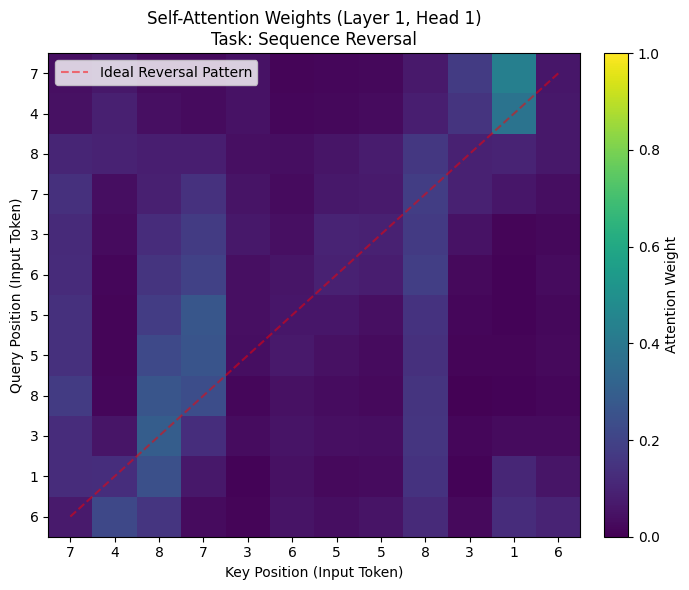


🔍 Sample Check:
Input:  [7 4 8 7 3 6 5 5 8 3 1 6]
Target: [6 1 3 8 5 5 6 3 7 8 4 7]
Pred:   [6 1 3 8 5 5 6 3 7 8 4 7]
Match:  True


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ========================
# 1. Transformer Components
# ========================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        assert self.d_k * num_heads == d_model, "d_model must be divisible by num_heads"
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None):
        B, T, D = x.shape
        q = self.W_q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attn_weights = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn_weights, v)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.W_o(out), attn_weights

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None):
        attn_out, attn_weights = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x, attn_weights

class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, 
                 num_layers: int, ff_dim: int, max_len: int = 50):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ff_dim) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        attn_weights_list = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask)
            attn_weights_list.append(attn_weights)
        return self.fc_out(x), attn_weights_list

# ========================
# 2. Training Setup
# ========================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VOCAB_SIZE = 10
SEQ_LEN = 12
BATCH_SIZE = 64
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 128
EPOCHS = 150

model = SimpleTransformer(VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, FF_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def generate_batch():
    src = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN), device=device)
    tgt = torch.flip(src, dims=[1])  # Task: reverse the sequence
    return src, tgt

print("🚀 Training transformer to reverse sequences...")
for epoch in range(EPOCHS):
    src, tgt = generate_batch()
    optimizer.zero_grad()
    logits, _ = model(src)
    loss = criterion(logits.view(-1, VOCAB_SIZE), tgt.view(-1))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

# ========================
# 3. Visualization
# ========================

model.eval()
with torch.no_grad():
    # Single sample for visualization
    src_sample = torch.randint(0, VOCAB_SIZE, (1, SEQ_LEN), device=device)
    _, attn_weights_list = model(src_sample)

# Extract attention from first layer, first head
attn = attn_weights_list[0][0, 0].cpu().numpy()  # shape: [SEQ_LEN, SEQ_LEN]

# Prepare plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn, cmap='viridis', aspect='auto', vmin=0, vmax=1)

# Add input tokens as labels
tokens = src_sample[0].cpu().numpy()
ax.set_xticks(range(SEQ_LEN))
ax.set_yticks(range(SEQ_LEN))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)
ax.set_xlabel("Key Position (Input Token)")
ax.set_ylabel("Query Position (Input Token)")
ax.set_title("Self-Attention Weights (Layer 1, Head 1)\nTask: Sequence Reversal")

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Attention Weight")

# Optional: draw anti-diagonal guide line
ax.plot([0, SEQ_LEN-1], [SEQ_LEN-1, 0], 'r--', alpha=0.5, label="Ideal Reversal Pattern")
ax.legend()

plt.tight_layout()
plt.show()

# Quick sanity check: show model prediction vs target
with torch.no_grad():
    logits, _ = model(src_sample)
    pred = torch.argmax(logits, dim=-1).cpu().numpy()[0]
    target = torch.flip(src_sample[0], dims=[0]).cpu().numpy()
    print("\n🔍 Sample Check:")
    print(f"Input:  {src_sample[0].cpu().numpy()}")
    print(f"Target: {target}")
    print(f"Pred:   {pred}")
    print(f"Match:  {np.array_equal(pred, target)}")